In [2]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

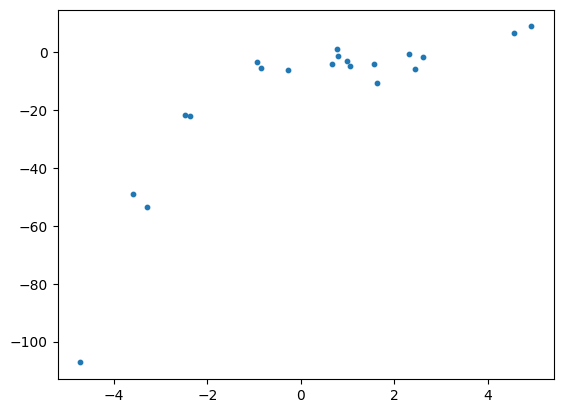

In [20]:
np.random.seed(0) #Set a random seed for reproducibility
X = 2 - 3 * np.random.normal(0, 1, 20) #Generate random
y = X - 2 * (X ** 2) + 0.5 * (X**3) + np.random.normal(-3, 3, 20) #Generate random
plt.scatter(X, y, s=10) #Plot the data points
plt.show()

In [46]:
X= X.reshape(-1,1)

# LINEAR REGRESSION

In [56]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X.reshape(-1, 1), y)

y_pred = lr.predict(X.reshape(-1, 1))
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error : {mse}")
print(f"R-squared : {r2}")

Mean Squared Error : 253.07217948430375
R-squared : 0.6386750054827146


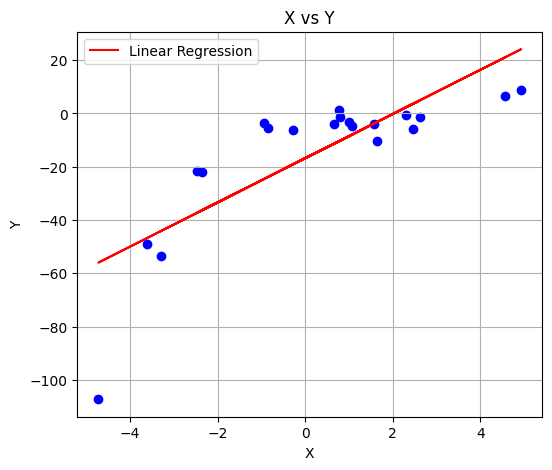

In [57]:
plt.figure(figsize=(6, 5))
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red', label="Linear Regression")
plt.title('X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()

# POLYNOMIAL REGRESSION

In [70]:
#Generating polynomial features
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X.reshape(X.shape[0], -1))
print(f"X_poly shape: {X_poly.shape}")

X_poly shape: (20, 4)


In [71]:
#Perform regression on the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

LinearRegression()

In [76]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred2 = lin_reg.predict(X_poly)
mse = mean_squared_error(y, y_pred2)
r2 = r2_score(y, y_pred2)

print(f"Mean Squared Error : {mse}")
print(f"R-squared : {r2}")

Mean Squared Error : 11.901779012038904
R-squared : 0.9830071790386679


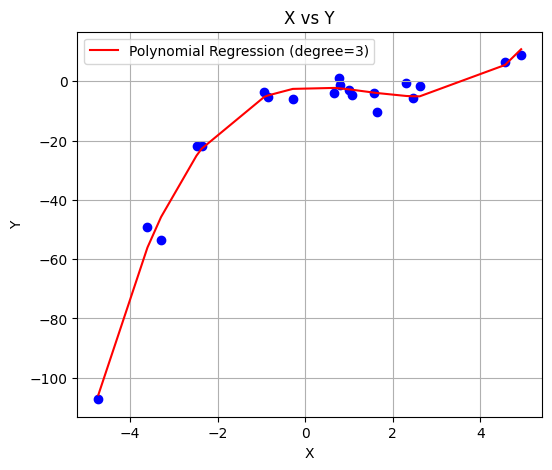

In [75]:
plt.figure(figsize=(6, 5))
plt.scatter(X, y, color='blue')

# Sort X values for a smooth plot
X_sorted = np.sort(X, axis=0)
X_poly_sorted = poly_features.transform(X_sorted)
y_pred_poly_sorted = lin_reg.predict(X_poly_sorted)

plt.plot(X_sorted, y_pred_poly_sorted, color='red', label=f'Polynomial Regression (degree={degree})')
plt.title('X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()